In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [6]:
##load dataset
df=pd.read_csv("House Price Prediction Dataset.csv")

In [7]:
df.head(7)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
5,6,3944,1,2,1,1906,Urban,Poor,No,93262
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722


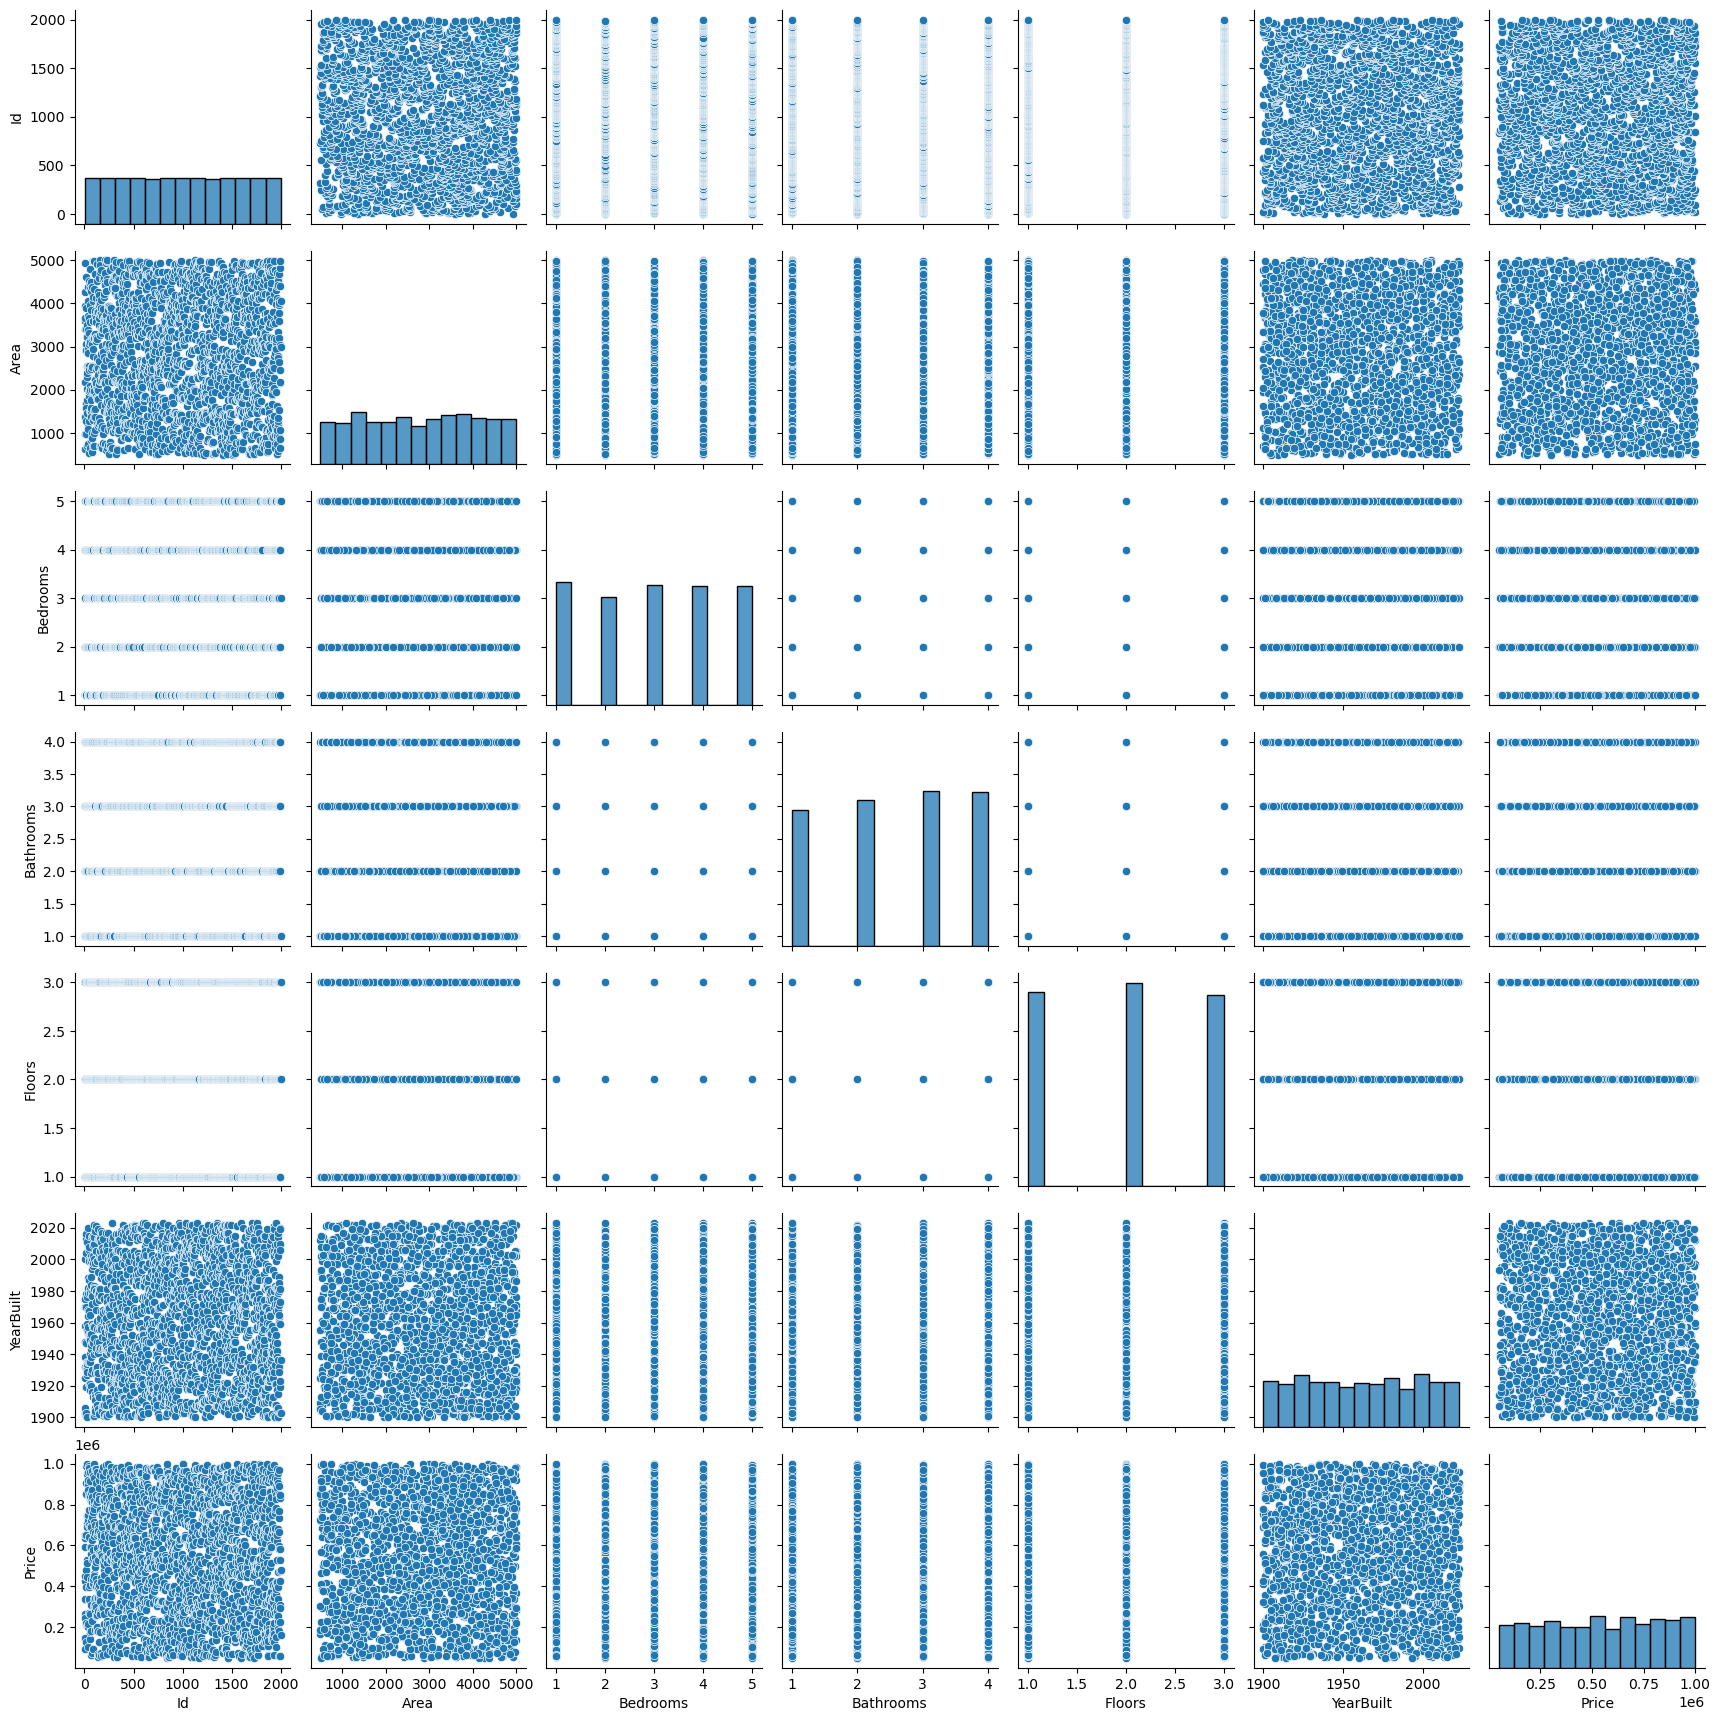

In [8]:
sns.pairplot(df)


Text(0, 0.5, 'Price of plot')

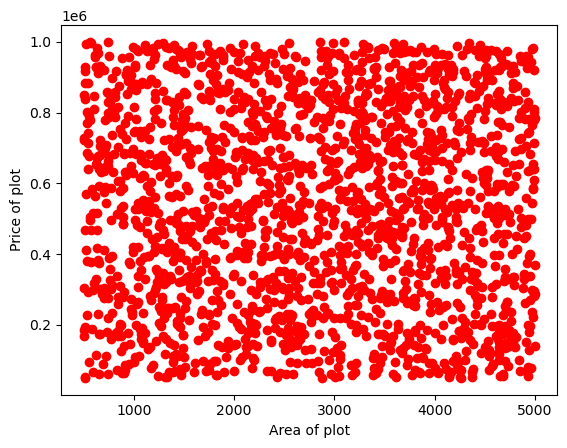

In [9]:
plt.scatter(df['Area'],df['Price'],color='r')
plt.xlabel('Area of plot')
plt.ylabel('Price of plot')

In [10]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [12]:
df.drop('Id',axis=1,inplace=True)

In [13]:
##label encoding
df['Garage']=np.where(df['Garage'].str.contains('Yes'),1,0)

In [14]:
condition_map={
    'Poor':0,
    'Fair':1,
    'Good':2,
    "Excellent":3
}
df['Condition']=df['Condition'].map(condition_map)

In [15]:
##one hot encoding
df=pd.get_dummies(df,columns=['Location'],drop_first=True)

In [16]:
df.head(7)

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Condition,Garage,Price,Location_Rural,Location_Suburban,Location_Urban
0,1360,5,4,3,1970,3,0,149919,False,False,False
1,4272,5,4,3,1958,3,0,424998,False,False,False
2,3592,2,2,3,1938,2,0,266746,False,False,False
3,966,4,2,2,1902,1,1,244020,False,True,False
4,4926,1,4,2,1975,1,1,636056,False,False,False
5,3944,1,2,1,1906,0,0,93262,False,False,True
6,3671,1,1,2,1948,0,1,448722,True,False,False


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Area               2000 non-null   int64
 1   Bedrooms           2000 non-null   int64
 2   Bathrooms          2000 non-null   int64
 3   Floors             2000 non-null   int64
 4   YearBuilt          2000 non-null   int64
 5   Condition          2000 non-null   int64
 6   Garage             2000 non-null   int32
 7   Price              2000 non-null   int64
 8   Location_Rural     2000 non-null   bool 
 9   Location_Suburban  2000 non-null   bool 
 10  Location_Urban     2000 non-null   bool 
dtypes: bool(3), int32(1), int64(7)
memory usage: 123.2 KB


In [18]:
current_year=2024
df['Age']=current_year-df['YearBuilt']

In [19]:
# df['Price']=df['Price']-df['Age']*2000

In [20]:
# df['Price']=df['Price']+(
#     df['Location_Urban']*50000+
#     df['Location_Suburban']*30000+
#     df['Location_Rural']*10000
# )

In [21]:
df['Price']=(
     df['Area']*300+
     df['Bedrooms']*50000+
     df['Bathrooms']*30000+
     df['Condition']*40000+
     df['Garage']*20000+
     df['Age']*2000+
     df['Location_Rural']*10000+
     df['Location_Suburban']*30000+
     df['Location_Urban']*50000
 )

In [22]:
##dependent and independent features
x=df.drop('Price',axis=1) ##features include area,bedroom ,condition etc
y=df['Price']   ##target is price based on features like area,bedroom ,condition etc

In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [24]:
x_test

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Condition,Garage,Location_Rural,Location_Suburban,Location_Urban,Age
1860,633,1,4,2,1901,1,0,False,False,True,123
353,3856,1,1,2,1901,1,0,False,False,True,123
1333,1598,5,4,1,2013,3,0,False,False,True,11
905,1705,3,1,2,1996,2,1,False,False,False,28
1289,2564,5,2,3,1994,2,1,False,False,False,30
...,...,...,...,...,...,...,...,...,...,...,...
765,2538,3,1,2,2021,0,0,False,True,False,3
1356,1291,4,3,2,2013,1,1,False,False,True,11
408,3767,4,2,3,2001,0,0,False,False,False,23
1614,4219,3,3,2,1982,0,0,True,False,False,42


In [25]:
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(n_estimators=500,max_depth=10,random_state=42)

In [26]:
model.fit(x_train,y_train)

RandomForestRegressor(max_depth=10, n_estimators=500, random_state=42)

In [27]:
pred=model.predict(x_test)

In [28]:
from sklearn.metrics import r2_score,mean_absolute_error

In [29]:
print('r2_score',r2_score(y_test,pred))
print('mae',mean_absolute_error(y_test,pred))

r2_score 0.9858183677932896
mae 38306.96636768786


In [30]:
print(x_train.shape)

(1500, 11)


In [31]:
print(x.columns)

Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Condition',
       'Garage', 'Location_Rural', 'Location_Suburban', 'Location_Urban',
       'Age'],
      dtype='object')


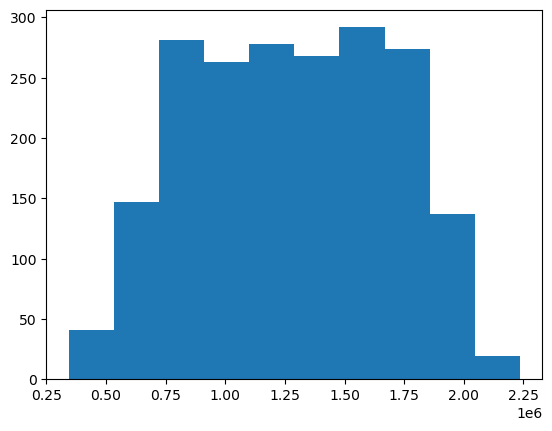

In [32]:
import matplotlib.pyplot as plt
plt.hist(df['Price'])
plt.show()

In [33]:
import pickle
pickle.dump(model, open('model.pkl','wb'))
pickle.dump(x.columns, open('columns.pkl','wb'))